**Table of contents**<a id='toc0_'></a>    
- [Imports](#toc1_)    
- [Load Data set](#toc2_)    
- [Understanding Data](#toc3_)    
- [Global constants](#toc4_)    
- [Model 1 - Classification](#toc5_)    
  - [Selecting 5 categories and labels](#toc5_1_)    
  - [Split data to train(fit) and test(predict)](#toc5_2_)    
    - [Understanding split data](#toc5_2_1_)    
  - [Using LDA clasification](#toc5_3_)    
    - [LDA without hyper parameter tuning](#toc5_3_1_)    
      - [Confusion matrix and other visualizations](#toc5_3_1_1_)    
    - [LDA with hyper parameter tuning](#toc5_3_2_)    
      - [Confusion matrix and other visualizations](#toc5_3_2_1_)    
    - [LDA with normalization and hyper parameter tuning](#toc5_3_3_)    
      - [Confusion matrix and other visualizations](#toc5_3_3_1_)    
  - [Logistic regression](#toc5_4_)    
    - [Without hyperparamter tuning](#toc5_4_1_)    
      - [Confusion matrix and other visualizations](#toc5_4_1_1_)    
    - [With hyperparameter Tuning](#toc5_4_2_)    
      - [Confusion matrix and other visualizations](#toc5_4_2_1_)    
    - [With Normalization](#toc5_4_3_)    
- [Model 2 - Preprocessing with classification](#toc6_)    
  - [Prerocessing with LDA feature/dimensionality reduction](#toc6_1_)    
    - [LDA without noramlisation and no hyper parameters](#toc6_1_1_)    
    - [LDA with noramlisation and no hyper parameters](#toc6_1_2_)    
    - [LDA with noramlisation and hyper parameters](#toc6_1_3_)    
      - [Optimization for finding best hyper parameters](#toc6_1_3_1_)    
        - [Grid search optimization to find best c value](#toc6_1_3_1_1_)    
  - [Prerocessing with HOG feature extraction reduction](#toc6_2_)    
- [Model 3 - CNN](#toc7_)    
  - [Model 3A - CNN without data agumentation](#toc7_1_)    
    - [Split Data and its overview](#toc7_1_1_)    
    - [CNN](#toc7_1_2_)    
  - [Model 3B - CNN with data agumentation](#toc7_2_)    
    - [Helper methods](#toc7_2_1_)    
      - [Image Augmented](#toc7_2_1_1_)    
    - [Image generation and split](#toc7_2_2_)    
    - [REMOVE CODE](#toc7_2_3_)    
    - [Understanding Split Data](#toc7_2_4_)    
    - [CNN defination and training](#toc7_2_5_)    
    - [Confusion matrix and accuracy curves](#toc7_2_6_)    
  - [Save the data and model](#toc7_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Imports](#toc0_)

In [ ]:
from matplotlib import pyplot as plt

import numpy as np

import seaborn as sns

import skimage.feature

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping #type: ignore
from tensorflow.keras.models import load_model #type: ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator #type: ignore

# <a id='toc2_'></a>[Load Data set](#toc0_)

In [ ]:
data = np.load('./Datasets/DS_Xdata.npy')
labels = np.load('./Datasets/Ydata.npy')

# <a id='toc3_'></a>[Understanding Data](#toc0_)

In [ ]:
print(f"Shape: {data.shape}")
print(f"Sample count: {len(labels)}")
print(f"Unique label: {np.unique(labels)}")

Shape: (2100, 61, 61, 3)
Sample count: 2100
Unique label: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


# <a id='toc4_'></a>[Global constants](#toc0_)

In [ ]:
#Value to replicate the random value generation in the file
seeding_constant = 20

#Categories to be selected for classification for model 1 and model 2
category_count = 5

label_classes = ['agricultural', 'airplane', 'baseball diamond', 'beach', 'buildings', 'chaparral', 'dense residential', 'forest', 
'freeway', 'golf course', 'harbour', 'intersection', 'medium residential', 'mobile home park', 'overpass', 'parking lot', 
'river', 'runway', 'sparse residential', 'storage tanks', 'tennis court']

# <a id='toc5_'></a>[Model 1 - Classification](#toc0_)

## <a id='toc5_1_'></a>[Selecting 5 categories and labels](#toc0_)

In [ ]:
np.random.seed(seeding_constant)

unique_label_set = set(np.unique(labels))

selected_categories = [np.random.randint(min(unique_label_set), 
                                         max(unique_label_set)) 
                        for _ in range(category_count)
                        ]

selected_data = [] 
selected_labels = [] 

for index, value in enumerate(labels):
    if value[0] in selected_categories:
        selected_data.append(data[index])
        selected_labels.append(value[0])

## <a id='toc5_2_'></a>[Split data to train(fit) and test(predict)](#toc0_)

In [ ]:
split_list = train_test_split(selected_data,
                              selected_labels,
                              test_size = 0.1,
                              shuffle = True,
                              random_state = seeding_constant                                      
                            )

train_model_1_and_2_data = split_list[0]
test_model_1_and_2_data = split_list[1]
train_model_1_and_2_labels = split_list[2]
test_model_1_and_2_labels = split_list[3]

### <a id='toc5_2_1_'></a>[Understanding split data](#toc0_)

In [ ]:
unique_train_labels = set(np.unique(train_model_1_and_2_labels))

print("Train Data diversification")
for i in unique_train_labels:
    print(f"Label {i} : {train_model_1_and_2_labels.count(i)}")

print("--"*25)

unique_test_labels = np.unique(test_model_1_and_2_labels)
print("Test Data diversification")
for i in unique_test_labels:
    print(f"Label {i} : {test_model_1_and_2_labels.count(i)}")

Train Data diversification
Label 3 : 87
Label 7 : 91
Label 9 : 93
Label 11 : 87
Label 15 : 92
--------------------------------------------------
Test Data diversification
Label 3 : 13
Label 7 : 9
Label 9 : 7
Label 11 : 13
Label 15 : 8


## <a id='toc5_3_'></a>[Using LDA clasification](#toc0_)

In [ ]:
# Reshape each image to a 1D array
num_features = np.prod(train_model_1_and_2_data[0].shape) 

train_model_1_and_2_data_reshaped = np.array([x.reshape(num_features) for x in train_model_1_and_2_data])
test_model_1_and_2_data_reshaped = np.array([x.reshape(num_features) for x in test_model_1_and_2_data])


### <a id='toc5_3_1_'></a>[LDA without hyper parameter tuning](#toc0_)

In [36]:
lda= LDA(n_components=3)
lda.fit(train_model_1_and_2_data_reshaped, train_model_1_and_2_labels)

result_model1 = lda.predict(test_model_1_and_2_data_reshaped)

In [ ]:
print(f"LDA Accuracy: {lda.score(test_model_1_and_2_data_reshaped, test_model_1_and_2_labels)}")

LDA Accuracy: 0.58


#### <a id='toc5_3_1_1_'></a>[Confusion matrix and other visualizations](#toc0_)

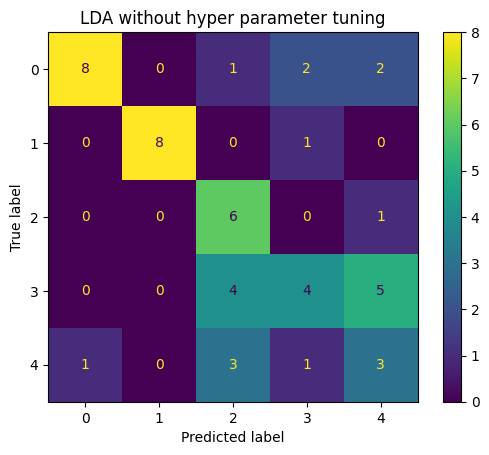

In [57]:
confusion_matrix_model11 = confusion_matrix(test_model_1_and_2_labels, result_model1)
ConfusionMatrixDisplay(confusion_matrix_model11).plot()
plt.title('LDA without hyper parameter tuning')
plt.show()

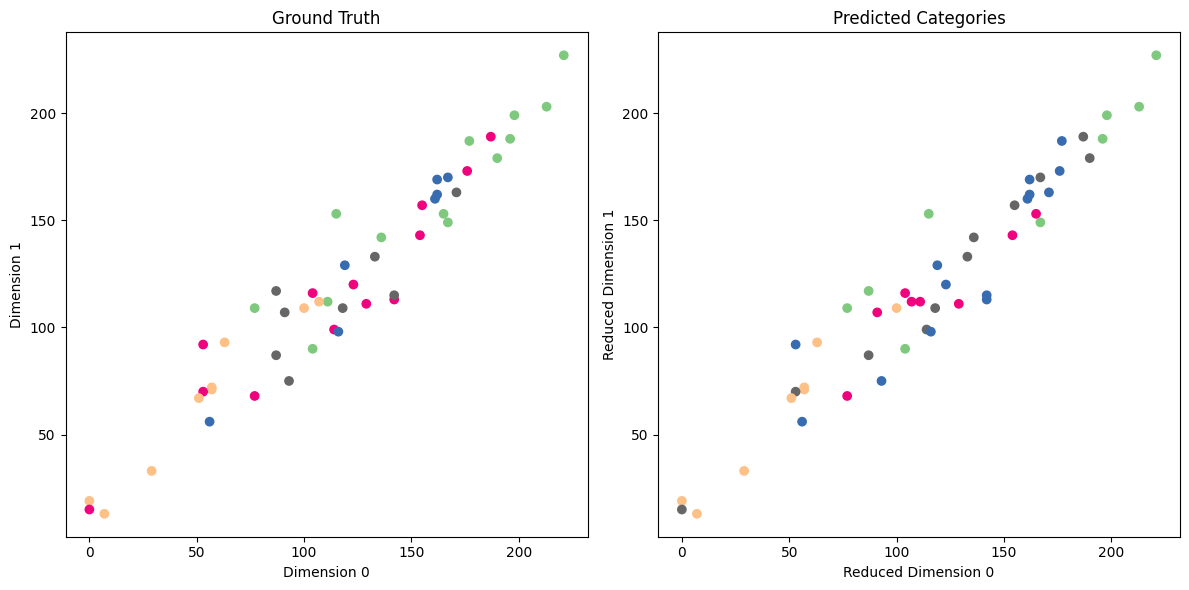

In [ ]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(test_model_1_and_2_data_reshaped[:,0], 
               test_model_1_and_2_data_reshaped[:,1],
               c=test_model_1_and_2_labels,
               cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(test_model_1_and_2_data_reshaped[:,0], 
               test_model_1_and_2_data_reshaped[:,1],
               c=result_model1,
               cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

### <a id='toc5_3_2_'></a>[LDA with hyper parameter tuning](#toc0_)

In [61]:
lda2= LDA(n_components=4, solver="eigen", shrinkage='auto' )
lda2.fit(train_model_1_and_2_data_reshaped, train_model_1_and_2_labels)

result2_model1 = lda2.predict(test_model_1_and_2_data_reshaped)


In [ ]:
print(lda2.score(test_model_1_and_2_data_reshaped, test_model_1_and_2_labels))

0.6


#### <a id='toc5_3_2_1_'></a>[Confusion matrix and other visualizations](#toc0_)

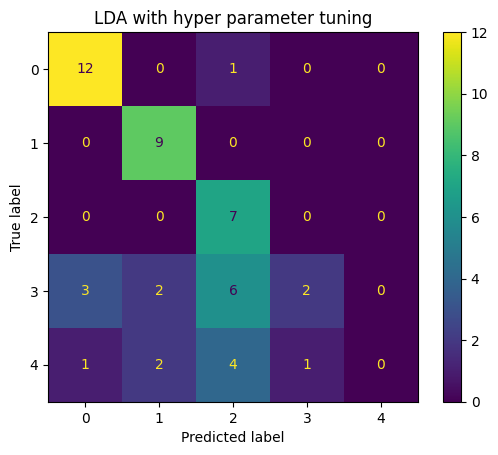

In [63]:
confusion_matrix_model12 = confusion_matrix(test_model_1_and_2_labels, result2_model1)
ConfusionMatrixDisplay(confusion_matrix_model12).plot()
plt.title('LDA with hyper parameter tuning')
plt.show()

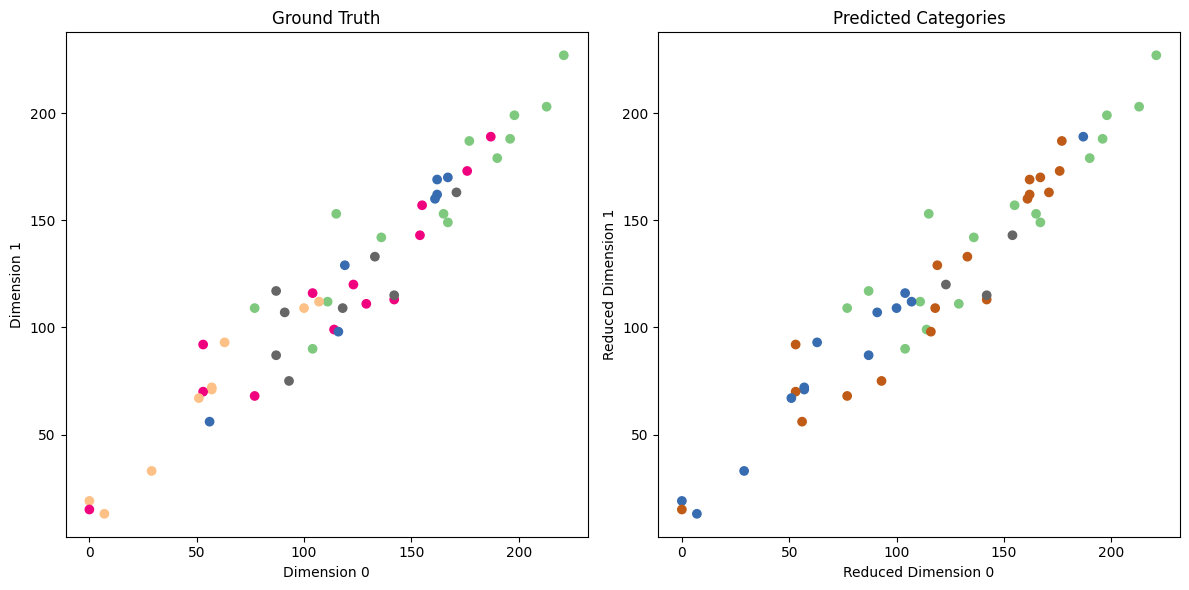

In [ ]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(test_model_1_and_2_data_reshaped[:,0], 
               test_model_1_and_2_data_reshaped[:,1],
               c=test_model_1_and_2_labels,
               cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(test_model_1_and_2_data_reshaped[:,0], 
               test_model_1_and_2_data_reshaped[:,1],
               c=result2_model1,
               cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

### <a id='toc5_3_3_'></a>[LDA with normalization and hyper parameter tuning](#toc0_)

In [65]:
lda3= LDA(n_components=4, solver="eigen", shrinkage='auto' )

normalized_train_data = train_model_1_and_2_data_reshaped/255
normalized_test_data = test_model_1_and_2_data_reshaped/255

lda3.fit(normalized_train_data, train_model_1_and_2_labels)

result3_model1 = lda3.predict(normalized_test_data)


In [ ]:
print(lda3.score(normalized_test_data, test_model_1_and_2_labels))

0.6


#### <a id='toc5_3_3_1_'></a>[Confusion matrix and other visualizations](#toc0_)

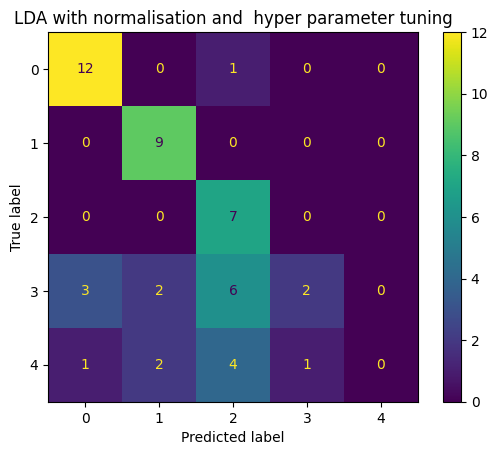

In [73]:
confusion_matrix_model13 = confusion_matrix(test_model_1_and_2_labels, result3_model1)
ConfusionMatrixDisplay(confusion_matrix_model13).plot()
plt.title('LDA with normalisation and  hyper parameter tuning')
plt.show()

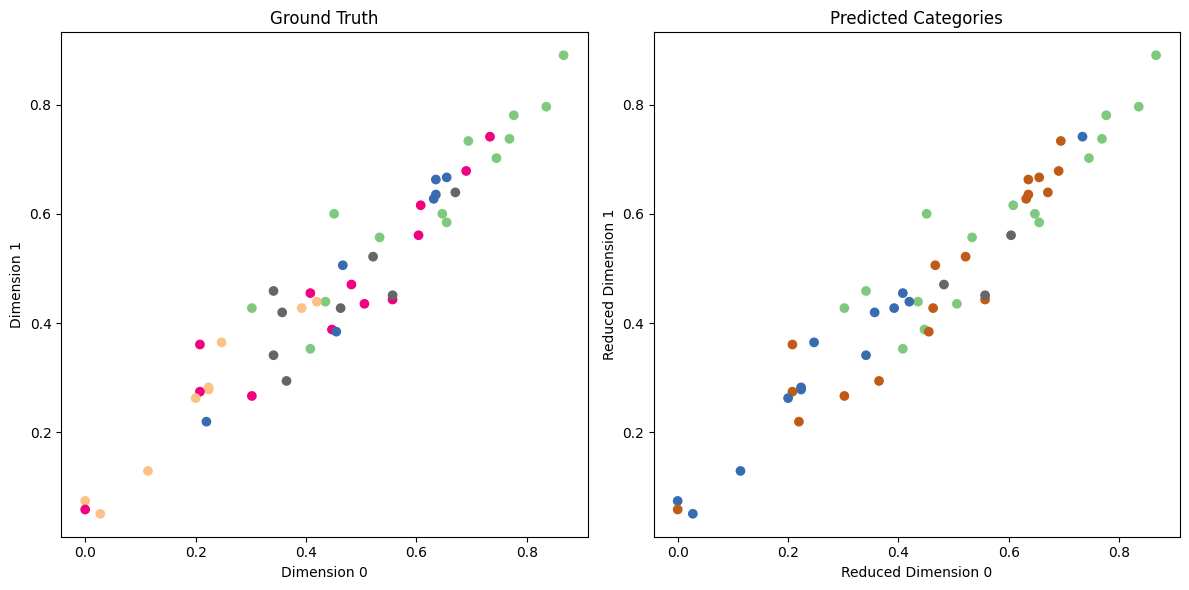

In [ ]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(normalized_test_data[:,0], 
               normalized_test_data[:,1],
               c=test_model_1_and_2_labels,
               cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(normalized_test_data[:,0], 
               normalized_test_data[:,1],
               c=result3_model1,
               cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

## <a id='toc5_4_'></a>[Logistic regression](#toc0_)

### <a id='toc5_4_1_'></a>[Without hyperparamter tuning](#toc0_)

In [ ]:
# Train a classifier on the reduced training data
classifier1 = LogisticRegression(max_iter=1000)
classifier1.fit(train_model_1_and_2_data_reshaped, train_model_1_and_2_labels)

# Predict labels for the reduced test data
predicted_labels1 = classifier1.predict(test_model_1_and_2_data_reshaped)

print(classifier1.score(test_model_1_and_2_data_reshaped, test_model_1_and_2_labels))

0.6


#### <a id='toc5_4_1_1_'></a>[Confusion matrix and other visualizations](#toc0_)

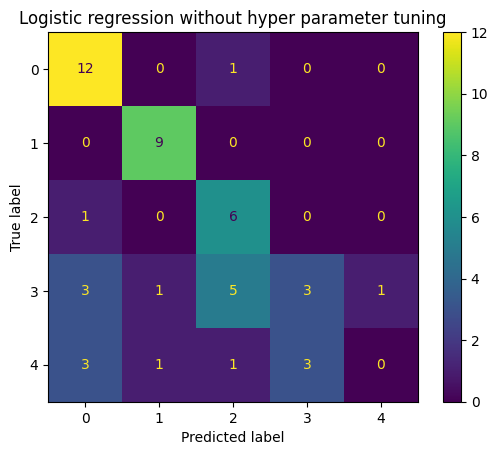

In [72]:
confusion_matrix_model14 = confusion_matrix(test_model_1_and_2_labels, predicted_labels1)
ConfusionMatrixDisplay(confusion_matrix_model14).plot()
plt.title('Logistic regression without hyper parameter tuning')
plt.show()

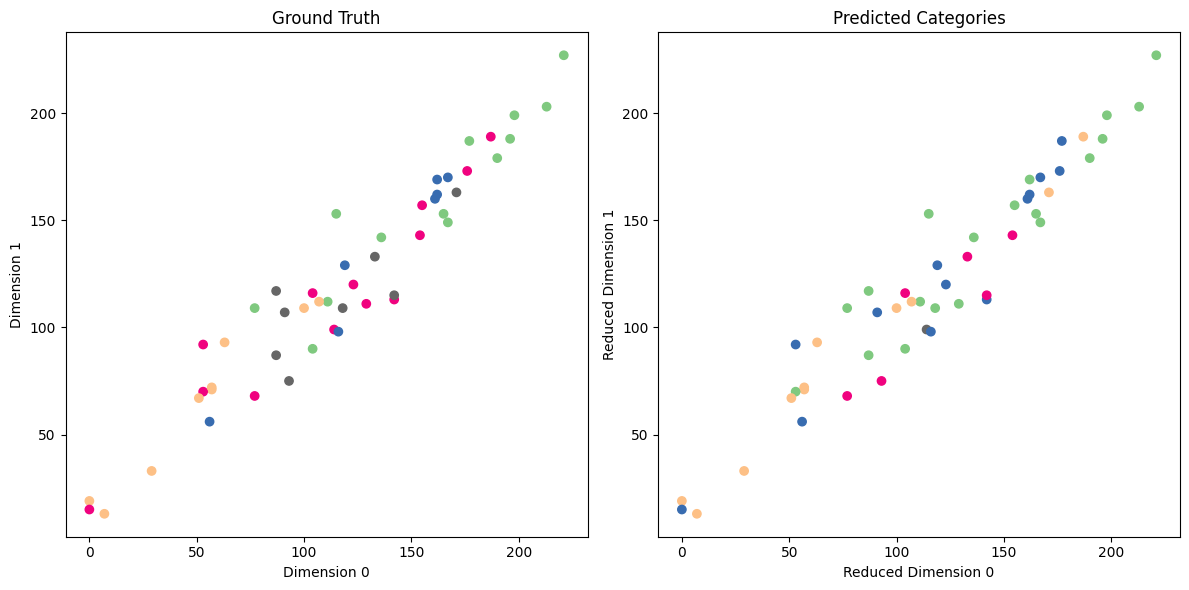

In [ ]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(test_model_1_and_2_data_reshaped[:,0], 
               test_model_1_and_2_data_reshaped[:,1],
               c=test_model_1_and_2_labels,
               cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(test_model_1_and_2_data_reshaped[:,0], 
               test_model_1_and_2_data_reshaped[:,1],
               c=predicted_labels1,
               cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

### <a id='toc5_4_2_'></a>[With hyperparameter Tuning](#toc0_)

In [ ]:
# Train a classifier on the reduced training data
#sag 15
classifier2 = LogisticRegression(max_iter=2500, solver='saga', C=2)
classifier2.fit(train_model_1_and_2_data_reshaped, train_model_1_and_2_labels)

# Predict labels for the reduced test data
predicted_labels2 = classifier2.predict(test_model_1_and_2_data_reshaped)

print(classifier2.score(test_model_1_and_2_data_reshaped, test_model_1_and_2_labels))

0.54


#### <a id='toc5_4_2_1_'></a>[Confusion matrix and other visualizations](#toc0_)

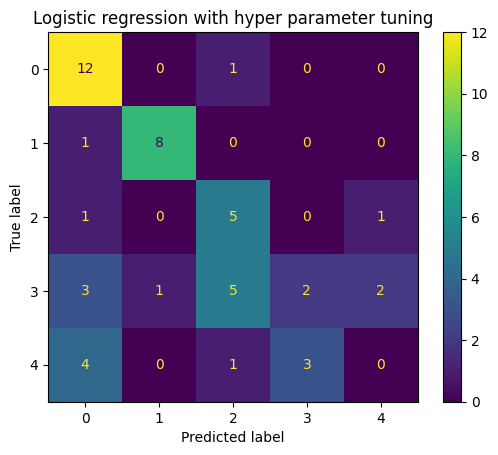

In [ ]:
confusion_matrix_model15 = confusion_matrix(test_model_1_and_2_labels, predicted_labels2)
ConfusionMatrixDisplay(confusion_matrix_model15).plot()
plt.title('Logistic regression with hyper parameter tuning')
plt.show()

### <a id='toc5_4_3_'></a>[With Normalization](#toc0_)

In [84]:
normalized_train_data = train_model_1_and_2_data_reshaped/255
normalized_test_data = test_model_1_and_2_data_reshaped/255

# Train a classifier on the reduced training data
classifier3 = LogisticRegression(max_iter=1000)
classifier3.fit(normalized_train_data, train_model_1_and_2_labels)

# Predict labels for the reduced test data
predicted_labels3 = classifier3.predict(normalized_test_data)

print(classifier3.score(normalized_test_data, test_model_1_and_2_labels))

0.62


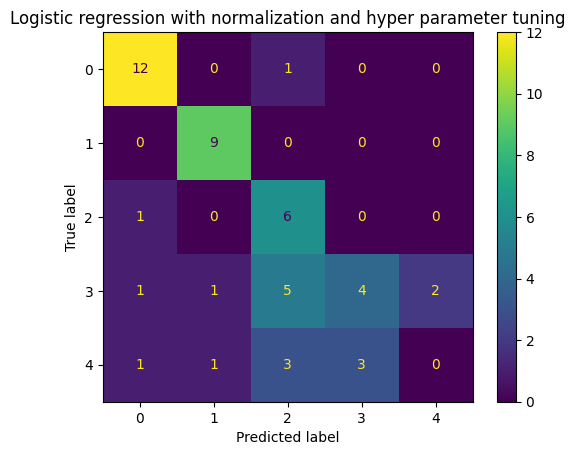

In [86]:
confusion_matrix_model16 = confusion_matrix(test_model_1_and_2_labels, predicted_labels3)
ConfusionMatrixDisplay(confusion_matrix_model16).plot()
plt.title('Logistic regression with normalization and hyper parameter tuning')
plt.show()

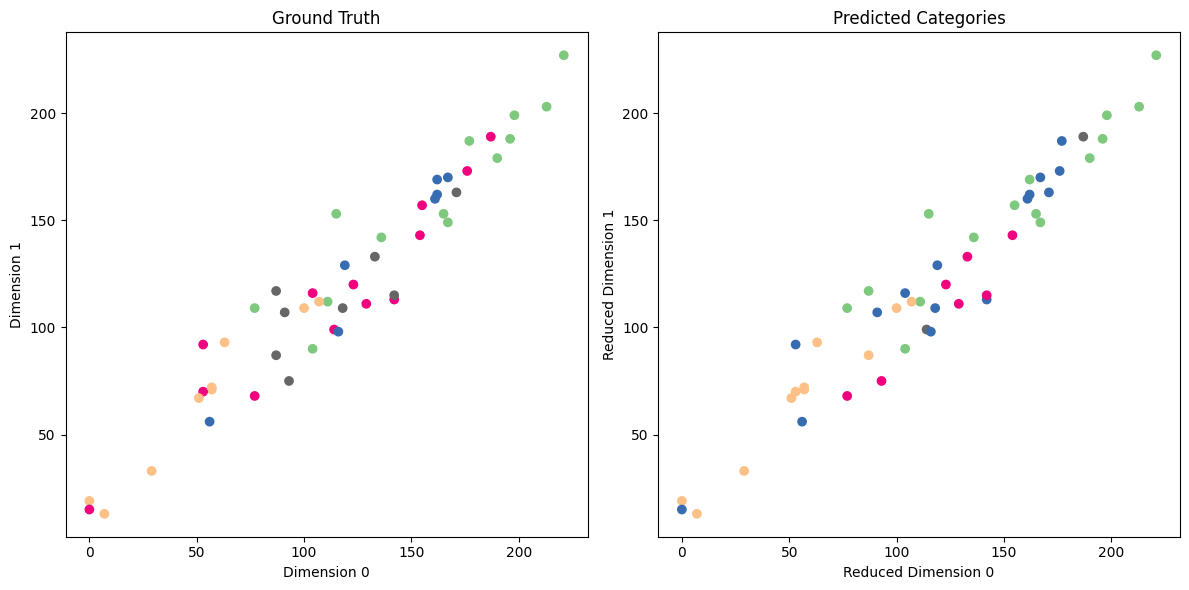

In [ ]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(test_model_1_and_2_data_reshaped[:,0], 
               test_model_1_and_2_data_reshaped[:,1],
               c=test_model_1_and_2_labels,
               cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(test_model_1_and_2_data_reshaped[:,0], 
               test_model_1_and_2_data_reshaped[:,1],
               c=predicted_labels3,
               cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

## SVM

In [ ]:
scaler = StandardScaler()

# Fit the scaler to the data and transform it
scaled_train_wine_data = scaler.fit_transform(train_wine_data)
scaled_test_wine_data = scaler.transform(test_wine_data)

fig, axes = plt.subplots(4, 4, figsize=(15, 15))
#Note: for kernel='precomputed', the input matrix should be a square matrix
for index, kernel in enumerate(['linear', 'poly', 'rbf', 'sigmoid']):
  for c in range(1, 5):
    svm = SVC(kernel=kernel, C=c)
    svm.fit(scaled_train_wine_data, train_wine_labels)
    print(f"Kernel:{kernel}, c:{c}, accuracy:", svm.score(scaled_test_wine_data, test_wine_labels))

    axes[index, c-1].set_title(f"Kernel:{kernel}, c:{c}")
    axes[index, c-1].scatter(test_wine_data[:, 0], test_wine_data[:, 1], c=svm.predict(scaled_test_wine_data))


plt.tight_layout()
plt.show()

# <a id='toc6_'></a>[Model 2 - Preprocessing with classification](#toc0_)

In [ ]:
# Reshape each image to a 1D array
num_features = np.prod(train_model_1_and_2_data[0].shape) 

train_model_1_and_2_data_reshaped = np.array([x.reshape(num_features) for x in train_model_1_and_2_data])
test_model_1_and_2_data_reshaped = np.array([x.reshape(num_features) for x in test_model_1_and_2_data])

## <a id='toc6_1_'></a>[Prerocessing with LDA feature/dimensionality reduction](#toc0_)

### <a id='toc6_1_1_'></a>[LDA without noramlisation and no hyper parameters](#toc0_)

In [92]:
lda4= LDA(n_components=4)
train_transformed1_moldel2 = lda4.fit_transform(train_model_1_and_2_data_reshaped, train_model_1_and_2_labels)

test_transformed1_moldel2 = lda4.transform(test_model_1_and_2_data_reshaped)

In [93]:
# Train a classifier on the reduced training data
classifier4 = LogisticRegression(max_iter=1000)
classifier4.fit(train_transformed1_moldel2, train_model_1_and_2_labels)

# Predict labels for the reduced test data
predicted_labels4 = classifier4.predict(test_transformed1_moldel2)

print(classifier4.score(test_transformed1_moldel2, test_model_1_and_2_labels))

0.62


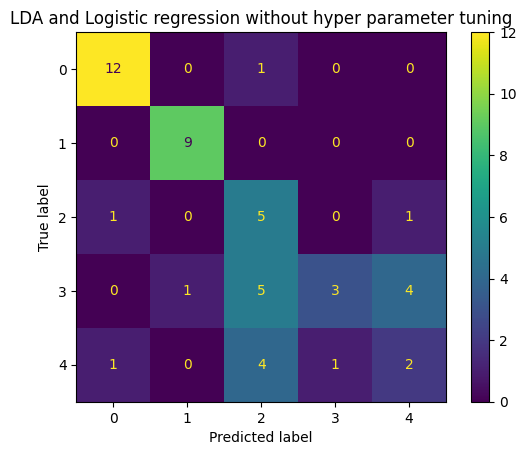

In [96]:
confusion_matrix_model21 = confusion_matrix(test_model_1_and_2_labels, predicted_labels4)
ConfusionMatrixDisplay(confusion_matrix_model21).plot()
plt.title('LDA and Logistic regression without hyper parameter tuning')
plt.show()

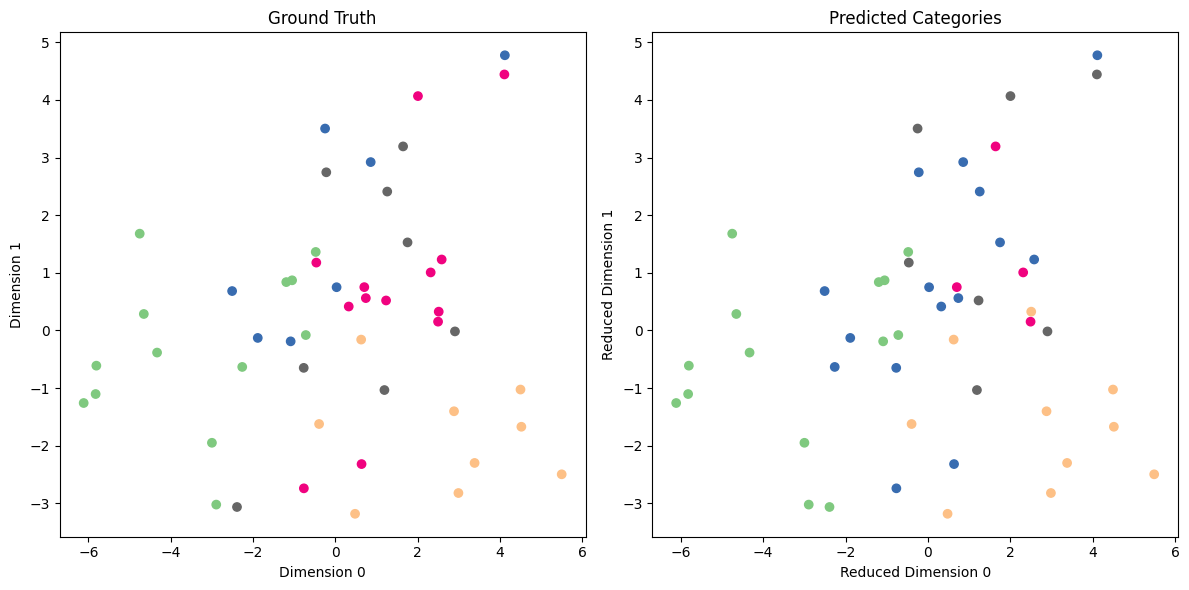

In [ ]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(test_transformed1_moldel2[:,0], 
               test_transformed1_moldel2[:,1],
               c=test_model_1_and_2_labels,
               cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(test_transformed1_moldel2[:,0], 
               test_transformed1_moldel2[:,1],
               c=predicted_labels4,
               cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

### <a id='toc6_1_2_'></a>[LDA with noramlisation and no hyper parameters](#toc0_)

In [98]:
normalized_train_data = train_model_1_and_2_data_reshaped/255
normalized_test_data = test_model_1_and_2_data_reshaped/255

In [99]:
lda5= LDA(n_components=4, )
train_transformed2_moldel2 = lda5.fit_transform(normalized_train_data, train_model_1_and_2_labels)

test_transformed2_moldel2 = lda5.transform(normalized_test_data)


In [100]:
# Train a classifier on the reduced training data
classifier5 = LogisticRegression(max_iter=1000)
classifier5.fit(train_transformed2_moldel2, train_model_1_and_2_labels)

# Predict labels for the reduced test data
predicted_labels5 = classifier5.predict(test_transformed2_moldel2)

print(classifier5.score(test_transformed2_moldel2, test_model_1_and_2_labels))

0.62


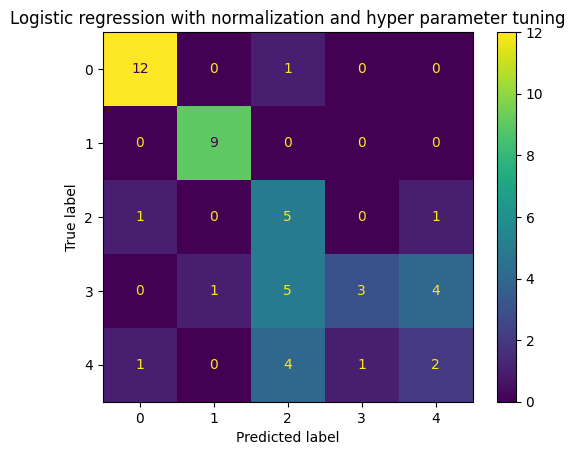

In [104]:
confusion_matrix_model22 = confusion_matrix(test_model_1_and_2_labels, predicted_labels5)
ConfusionMatrixDisplay(confusion_matrix_model22).plot()
plt.title('Logistic regression with normalization and hyper parameter tuning')
plt.show()

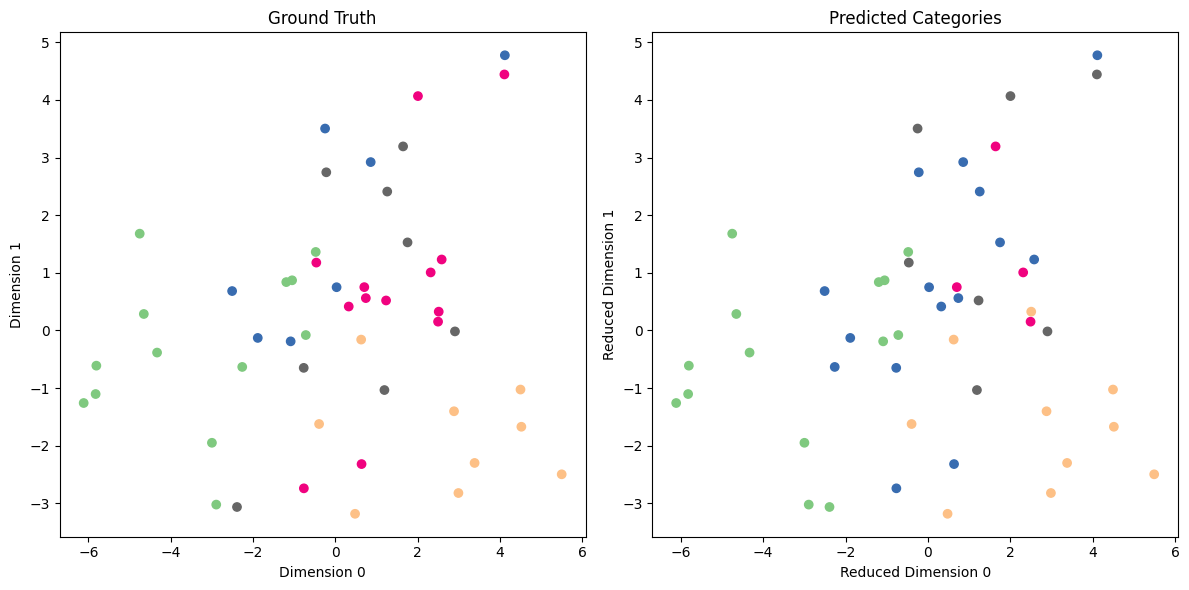

In [ ]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(test_transformed2_moldel2[:,0], 
               test_transformed2_moldel2[:,1],
               c=test_model_1_and_2_labels,
               cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(test_transformed2_moldel2[:,0], 
               test_transformed2_moldel2[:,1],
               c=predicted_labels5,
               cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

### <a id='toc6_1_3_'></a>[LDA with noramlisation and hyper parameters](#toc0_)

In [105]:
lda6= LDA(n_components=3, solver="eigen", shrinkage='auto')
train_transformed3_moldel2 = lda6.fit_transform(normalized_train_data, train_model_1_and_2_labels)

test_transformed3_moldel2 = lda6.transform(normalized_test_data)


In [106]:
classifier6 = LogisticRegression(max_iter=1000, C=5.294)
classifier6.fit(train_transformed3_moldel2, train_model_1_and_2_labels)

# Predict labels for the reduced test data
predicted_labels6 = classifier6.predict(test_transformed3_moldel2)
print(f"{classifier6.score(test_transformed3_moldel2, test_model_1_and_2_labels)}")

0.6


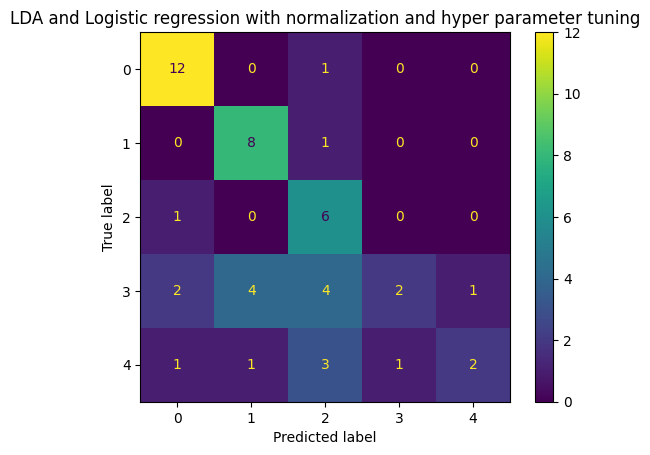

In [109]:
confusion_matrix_model23 = confusion_matrix(test_model_1_and_2_labels, predicted_labels6)
ConfusionMatrixDisplay(confusion_matrix_model23).plot()
plt.title('LDA and Logistic regression with normalization and hyper parameter tuning')
plt.show()

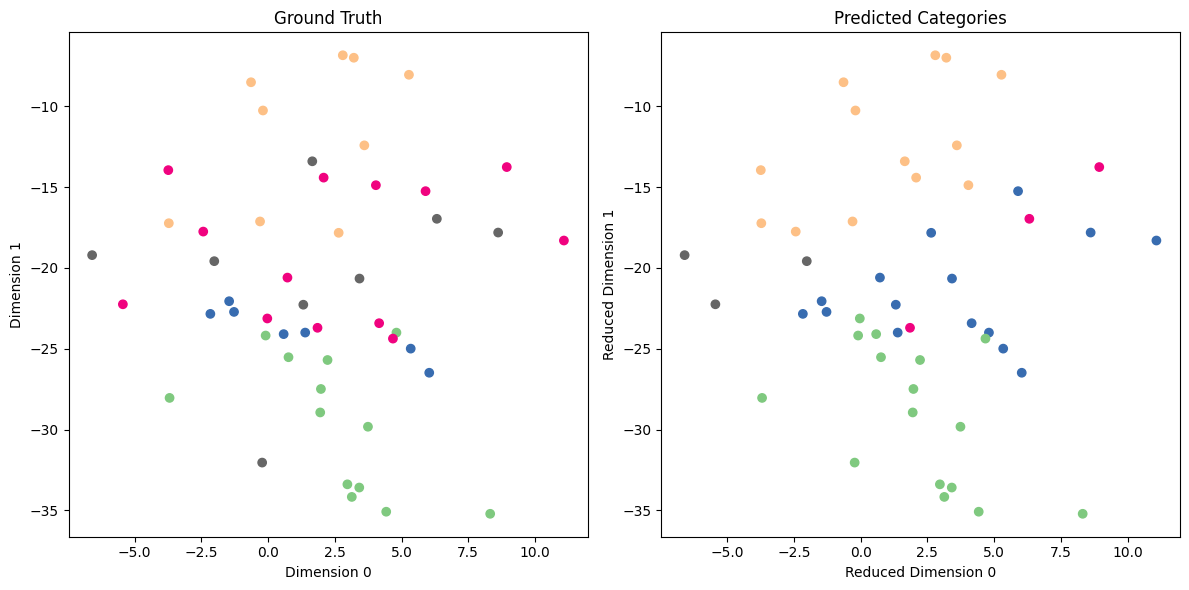

In [ ]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(test_transformed3_moldel2[:,0], 
               test_transformed3_moldel2[:,1],
               c=test_model_1_and_2_labels,
               cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(test_transformed3_moldel2[:,0], 
               test_transformed3_moldel2[:,1],
               c=predicted_labels6,
               cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

#### <a id='toc6_1_3_1_'></a>[Optimization for finding best hyper parameters](#toc0_)

##### <a id='toc6_1_3_1_1_'></a>[Grid search optimization to find best c value](#toc0_)

In [111]:
# Train a classifier on the reduced training data
for i in np.linspace(5, 7, 10000):
    classifier6 = LogisticRegression(max_iter=1000, C=round(float(i), 3))
    classifier6.fit(train_transformed3_moldel2, train_model_1_and_2_labels)

    # Predict labels for the reduced test data
    predicted_labels6 = classifier6.predict(test_transformed3_moldel2)
    score = classifier6.score(test_transformed3_moldel2, test_model_1_and_2_labels)
    if(score>0.58):
        print(f"{round(float(i), 3)}:{score}")

5.294:0.6
5.294:0.6
5.294:0.6
5.294:0.6
5.294:0.6
6.091:0.6
6.091:0.6
6.091:0.6
6.091:0.6
6.091:0.6


In [ ]:
classifier6 = LogisticRegression(max_iter=1000, C=5.294)
classifier6.fit(train_transformed3_moldel2, train_model_1_and_2_labels)

# Predict labels for the reduced test data
predicted_labels6 = classifier6.predict(test_transformed3_moldel2)
score = classifier6.score(test_transformed3_moldel2, test_model_1_and_2_labels)
print(score)

0.6


## <a id='toc6_2_'></a>[Prerocessing with HOG feature extraction reduction](#toc0_)

In [ ]:
hog_features = []

for index, image in enumerate(np.array(selected_data)):
    hog_feature, hog_image = skimage.feature.hog(image, 
                                                 pixels_per_cell=[10, 10], 
                                                 cells_per_block=[5, 5], 
                                                 visualize=True,
                                                 channel_axis=2
                                                )

    hog_features.append(hog_feature)

In [ ]:
np.array(hog_features).shape

In [ ]:
split_list_post_hog = train_test_split(hog_features,
                                       selected_labels,
                              test_size = 0.1,
                              shuffle = True,
                              random_state = seeding_constant                                      
                            )

train_data_post_hog = np.array(split_list_post_hog[0])
test_data_post_hog = np.array(split_list_post_hog[1])

train_labels_post_hog = np.array(split_list_post_hog[2])
test_labels_post_hog = np.array(split_list_post_hog[3])


In [ ]:
classifier7 = LogisticRegression(max_iter=1000)
classifier7.fit(train_data_post_hog, train_labels_post_hog)

# Predict labels for the reduced test data
predicted_labels7 = classifier7.predict(test_data_post_hog)
print(f"{classifier7.score(test_data_post_hog, test_labels_post_hog)}")

In [ ]:
plt.ion()
# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(test_data_post_hog[:,2], 
            test_data_post_hog[:,3],
            c=test_labels_post_hog,
            cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(test_data_post_hog[:,2], 
            test_data_post_hog[:,3],
            c=predicted_labels7,
            cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

In [ ]:
# Start interactive mode
plt.ion()

    # Create the figure and subplots for 3D plots (one 3D subplot for each)
fig = plt.figure(figsize=(15, 7))
ax1 = fig.add_subplot(121, projection='3d')  # Ground truth plot
ax2 = fig.add_subplot(122, projection='3d')  # Predicted categories plot

# Plot ground truth (3D)
scatter1 = ax1.scatter(test_data_post_hog[:, 2], 
                        test_data_post_hog[:, 3],
                        test_data_post_hog[:, 4],  # Adding third dimension
                        c=test_labels_post_hog, 
                        cmap='Accent')
ax1.set_xlabel("Dimension 0")
ax1.set_ylabel("Dimension 1")
ax1.set_zlabel("Dimension 2")
ax1.set_title(f"Ground Truth : {i}")

# Plot predicted truth (3D)
scatter2 = ax2.scatter(test_data_post_hog[:, 2], 
                        test_data_post_hog[:, 3],
                        test_data_post_hog[:, 4],  # Adding third dimension
                        c=predicted_labels7, 
                        cmap='Accent')
ax2.set_xlabel("Dimension 0")
ax2.set_ylabel("Dimension 1")
ax2.set_zlabel("Dimension 2")
ax2.set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

# Turn off interactive mode and show the plot at the end
plt.show()

# <a id='toc7_'></a>[Model 3 - CNN](#toc0_)

## <a id='toc7_1_'></a>[Model 3A - CNN without data agumentation](#toc0_)

### <a id='toc7_1_1_'></a>[Split Data and its overview](#toc0_)

In [29]:
split_list_cnn = train_test_split(data,
                              labels,
                              test_size = 0.1,
                              shuffle = True,
                              random_state = seeding_constant                                      
                            )

train_cnn_data = split_list_cnn[0]
train_cnn_labels = split_list_cnn[2]

test_cnn_data = split_list_cnn[1]
test_cnn_labels= split_list_cnn[3]

In [30]:
unique_train_cnn_labels = set(np.unique(train_cnn_labels))

print("Train Data diversification")
for i in unique_train_cnn_labels:
    print(f"Label {i} : {list(train_cnn_labels).count(i)}")

Train Data diversification
Label 0 : 90
Label 1 : 91
Label 2 : 88
Label 3 : 89
Label 4 : 81
Label 5 : 89
Label 6 : 92
Label 7 : 89
Label 8 : 89
Label 9 : 91
Label 10 : 94
Label 11 : 91
Label 12 : 96
Label 13 : 91
Label 14 : 94
Label 15 : 90
Label 16 : 90
Label 17 : 89
Label 18 : 90
Label 19 : 88
Label 20 : 88


In [ ]:
unique_test_cnn_labels = np.unique(test_cnn_labels)
print("Test Data diversification")
for i in unique_test_cnn_labels:
    print(f"Label {i} : {list(test_cnn_labels).count(i)}")

Test Data diversification
Label 0 : 10
Label 1 : 9
Label 2 : 12
Label 3 : 11
Label 4 : 19
Label 5 : 11
Label 6 : 8
Label 7 : 11
Label 8 : 11
Label 9 : 9
Label 10 : 6
Label 11 : 9
Label 12 : 4
Label 13 : 9
Label 14 : 6
Label 15 : 10
Label 16 : 10
Label 17 : 11
Label 18 : 10
Label 19 : 12
Label 20 : 12


### <a id='toc7_1_2_'></a>[CNN](#toc0_)

In [32]:
normalized_cnn_train_data = train_cnn_data/255
normalized_cnn_test_data = test_cnn_data/255

In [47]:
#Filter variables for cnn
filter_count = 32
multiplier=0

#Define the model with layers and hyperparams as per requiremnets
model_cnn = tf.keras.Sequential(layers=[
    tf.keras.layers.Conv2D(filter_count, kernel_size=(3,3), activation=tf.nn.leaky_relu),    
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(filter_count*(2**(multiplier+1)), kernel_size=(3,3), activation=tf.nn.relu),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(filter_count*(2**(multiplier+1)), kernel_size=(3,3), activation=tf.nn.relu, use_bias=True),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(filter_count*(2**(multiplier+2)), kernel_size=(3,3), activation=tf.nn.elu, use_bias=True),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(filter_count*(2**(multiplier+4)), activation=tf.nn.elu, use_bias=True),
    tf.keras.layers.Dropout(0.6),
    tf.keras.layers.Dense(len(np.unique(labels)), activation = tf.nn.softmax)])

#Add the optimizer, loss, metrics and finalize the configuration
model_cnn.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss = tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics = [tf.keras.metrics.SparseCategoricalAccuracy()])

#Train the model with train data set and include validation to see the accuracy
history_cnn = model_cnn.fit(normalized_cnn_train_data,
                                train_cnn_labels,
                                epochs = 20,
                                validation_split = 0.1,
                                verbose = 1
                                )

Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 4.1935 - sparse_categorical_accuracy: 0.1143 - val_loss: 3.1475 - val_sparse_categorical_accuracy: 0.0476
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 2.3016 - sparse_categorical_accuracy: 0.3481 - val_loss: 3.4856 - val_sparse_categorical_accuracy: 0.0317
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 1.7035 - sparse_categorical_accuracy: 0.4806 - val_loss: 3.8535 - val_sparse_categorical_accuracy: 0.0317
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 1.3784 - sparse_categorical_accuracy: 0.5732 - val_loss: 4.0440 - val_sparse_categorical_accuracy: 0.0317
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 1.1846 - sparse_categorical_accuracy: 0.6316 - val_loss: 3.8584 - val_sparse_categorical_accuracy: 0.0476
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.9184 - sparse_categorical_accuracy: 0.7111 - val_loss: 3.7501 - val_sparse_categorical_accuracy: 0.0476
Epoch 7/20

In [48]:
model_cnn.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)              │ (None, 59, 59, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 59, 59, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 29, 29, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 27, 27, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 27, 27, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 25, 25, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 25, 25, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 512)            │     1,638,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 21)             │        10,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,340,865 (20.37 MB)

 Trainable params: 1,780,181 (6.79 MB)

 Non-trainable params: 320 (1.25 KB)

 Optimizer params: 3,560,364 (13.58 MB)

In [49]:
#Use the testing data to check the accuraccy and if the model needs any tuning
results_cnn = model_cnn.evaluate(normalized_cnn_test_data, test_cnn_labels)

print(f'Test set loss: {results_cnn[0]:0.2f}, test set accuracy: {results_cnn[1]*100:0.2f}%')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.2594 - sparse_categorical_accuracy: 0.7206
Test set loss: 1.16, test set accuracy: 70.95%


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


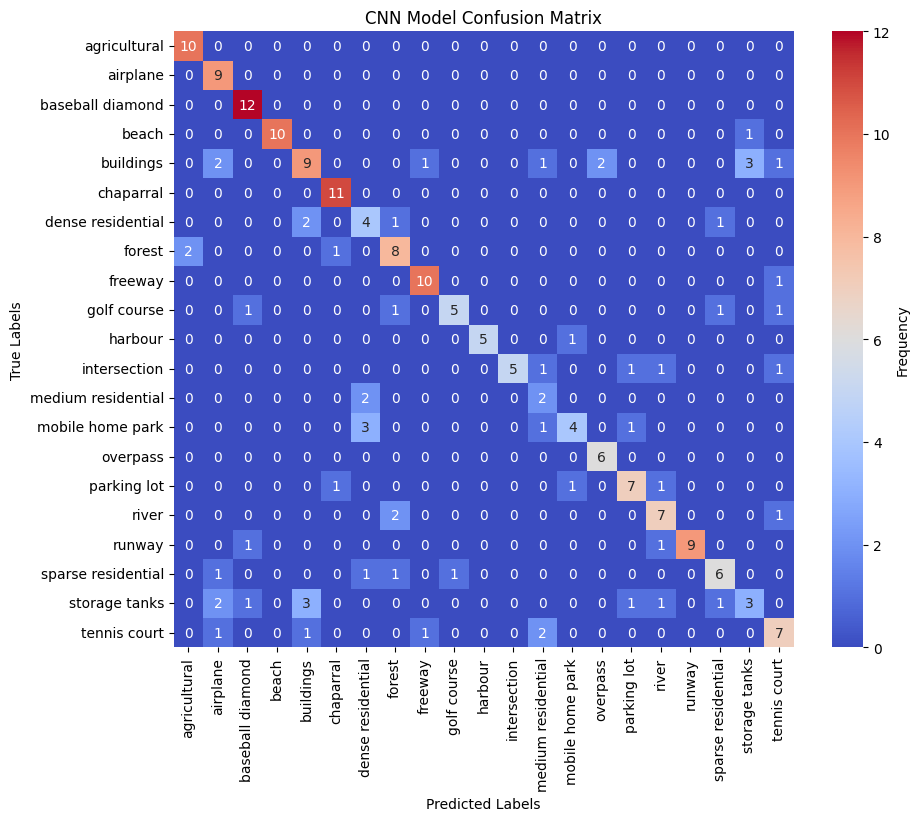

In [50]:
# Generate predictions and confusion matrix
predicted_labels_matrix = model_cnn.predict(normalized_cnn_test_data)
predicted_labels_cnn = np.argmax(predicted_labels_matrix, axis=1)
confusion_matrix_model31 = confusion_matrix(test_cnn_labels, predicted_labels_cnn)

# Customization
fig, ax = plt.subplots(figsize=(10, 8))  # Adjust figure size
sns.heatmap(confusion_matrix_model31, 
            annot=True, 
            fmt='d', 
            cmap='coolwarm',  # Change colormap
            xticklabels=label_classes,  # Adjust labels
            yticklabels=label_classes,
            cbar_kws={'label': 'Frequency'},  # Add color bar label
            ax=ax)

plt.title('CNN Model Confusion Matrix')  # Title
plt.ylabel('True Labels')  # Y-axis label
plt.xlabel('Predicted Labels')  # X-axis label
plt.show()


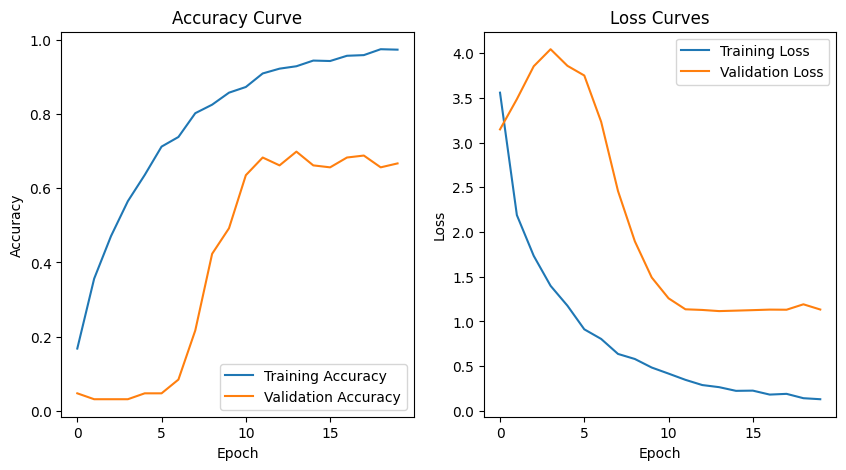

In [ ]:
plt.figure(figsize=[10,5])

#Plot lines for training vs validation accuracy
plt.subplot(121)
plt.plot(history_cnn.history['sparse_categorical_accuracy'])
plt.plot(history_cnn.history['val_sparse_categorical_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy',
           'Validation Accuracy'])
plt.title('Accuracy Curve')

#Plot lines for training vs validation loss
plt.subplot(122)
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training Loss',
           'Validation Loss'])
plt.title('Loss Curves')

plt.show()

## <a id='toc7_2_'></a>[Model 3B - CNN with data agumentation](#toc0_)

### <a id='toc7_2_1_'></a>[Helper methods](#toc0_)

#### <a id='toc7_2_1_1_'></a>[Image Augmented](#toc0_)

In [ ]:
def image_generator(image, num_augmented_images = 5):
    # Set up the ImageDataGenerator with your desired augmentations
    datagen = ImageDataGenerator(
        rotation_range=0,             # No random rotations
        shear_range=0.2,              # Shear transformations
        zoom_range=0.2,               # Zoom range (20%)
        horizontal_flip=True,         # Horizontal flip
        vertical_flip=True,           # Vertical flip
        fill_mode='nearest'  # Use custom rotation function
    )

    img_array = np.expand_dims(image, axis=0)  # Add a batch dimension

    # Array to hold augmented images
    augmented_images = []

    # Number of augmented images to generate
    num_augmented_images = 5

    # Generate augmented images and store them in the array
    for batch in datagen.flow(img_array, batch_size=1):
        augmented_images.append(batch[0])  # Add the augmented image to the list
        if len(augmented_images) >= num_augmented_images:
            break  # Stop after generating the desired number of augmented images


    # Convert the list of augmented images to a NumPy array for easier processing
    augmented_images_array = np.array(augmented_images)

    augmented_image_array_270=np.rot90(augmented_images_array, axes=(1,2))
    augmented_image_array_180=np.rot90(augmented_images_array, k=2)
    augmented_image_array_90=np.rot90(augmented_images_array, k=3, axes=(1,2))

    # merge all the images to a single array
    all_images_array = np.concatenate((augmented_images_array, augmented_image_array_90, augmented_image_array_180, augmented_image_array_270))

    return all_images_array


### <a id='toc7_2_2_'></a>[Image generation and split](#toc0_)

### <a id='toc7_2_3_'></a>[REMOVE CODE](#toc0_)

In [5]:
# augmented_images = np.load('./Datasets/agumented_data.npy')
# augmented_label_list = np.load('./Datasets/agumented_label_list.npy')

In [ ]:
augmented_images = np.array(np.copy(data))
augmented_label_list = np.copy(labels).flatten()

for i in range(len(data)):
    # Extract the image and its corresponding label
    images_result= image_generator(data[i, :, :, :])
    # Append the augmented images to the list
    augmented_images = np.concatenate((augmented_images, images_result))

    repeated_labels = np.repeat(labels[i], images_result.shape[0])  # Repeat the label for the batch of images
    
    # Append the repeated labels
    augmented_label_list = np.concatenate((augmented_label_list, repeated_labels))

In [ ]:
split_list_cnn_augmented = train_test_split(augmented_images,
                              augmented_label_list,
                              test_size = 0.1,
                              shuffle = True,
                              random_state = seeding_constant                                      
                            )

train_cnn_data_augmented = split_list_cnn_augmented[0]
train_cnn_labels_augmented = split_list_cnn_augmented[2]

test_cnn_data_augmented = split_list_cnn_augmented[1]
test_cnn_labels_augmented = split_list_cnn_augmented[3]

### <a id='toc7_2_4_'></a>[Understanding Split Data](#toc0_)

In [7]:
unique_train_cnn_labels = set(np.unique(train_cnn_labels_augmented))

print("Train Data diversification")
for i in unique_train_cnn_labels:
    print(f"Label {i} : {list(train_cnn_labels_augmented).count(i)}")

Train Data diversification
Label 0 : 1884
Label 1 : 1889
Label 2 : 1899
Label 3 : 1911
Label 4 : 1896
Label 5 : 1902
Label 6 : 1874
Label 7 : 1889
Label 8 : 1891
Label 9 : 1909
Label 10 : 1870
Label 11 : 1897
Label 12 : 1874
Label 13 : 1884
Label 14 : 1891
Label 15 : 1872
Label 16 : 1867
Label 17 : 1883
Label 18 : 1910
Label 19 : 1908
Label 20 : 1890


In [ ]:
unique_test_cnn_labels = np.unique(test_cnn_labels_augmented)
print("Test Data diversification")
for i in unique_test_cnn_labels:
    print(f"Label {i} : {list(test_cnn_labels_augmented).count(i)}")

Test Data diversification
Label 0 : 216
Label 1 : 211
Label 2 : 201
Label 3 : 189
Label 4 : 204
Label 5 : 198
Label 6 : 226
Label 7 : 211
Label 8 : 209
Label 9 : 191
Label 10 : 230
Label 11 : 203
Label 12 : 226
Label 13 : 216
Label 14 : 209
Label 15 : 228
Label 16 : 233
Label 17 : 217
Label 18 : 190
Label 19 : 192
Label 20 : 210


### <a id='toc7_2_5_'></a>[CNN defination and training](#toc0_)

In [16]:
normalized_cnn_train_data_augmented = train_cnn_data_augmented/255
normalized_cnn_test_data_augmented = test_cnn_data_augmented/255

In [17]:
#Filter variables for cnn
filter_count = 32
multiplier=0

early_stopping = EarlyStopping(monitor='val_loss', patience=1, restore_best_weights=True, verbose=1)


#Define the model with layers and hyperparams as per requiremnets
model_cnn_augmented = tf.keras.Sequential(layers=[
    tf.keras.layers.Conv2D(filter_count, kernel_size=(3,3), activation=tf.nn.leaky_relu),    
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(filter_count*(2**(multiplier+1)), kernel_size=(3,3), activation=tf.nn.relu),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(filter_count*(2**(multiplier+1)), kernel_size=(3,3), activation=tf.nn.relu, use_bias=True),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(filter_count*(2**(multiplier+2)), kernel_size=(3,3), activation=tf.nn.elu, use_bias=True),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(filter_count*(2**(multiplier+4)), activation=tf.nn.elu, use_bias=True),
    tf.keras.layers.Dropout(0.6),
    tf.keras.layers.Dense(len(np.unique(labels)), activation = tf.nn.softmax)])

#Add the optimizer, loss, metrics and finalize the configuration
model_cnn_augmented.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss = tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics = [tf.keras.metrics.SparseCategoricalAccuracy()])

#Train the model with train data set and include validation to see the accuracy
history_cnn_augmeneted = model_cnn_augmented.fit(normalized_cnn_train_data_augmented,
                                train_cnn_labels_augmented,
                                epochs = 8,
                                validation_split = 0.1,
                                verbose = 1,
                                callbacks=[early_stopping]
                                )

Epoch 1/8
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 165s 141ms/step - loss: 2.1986 - sparse_categorical_accuracy: 0.3957 - val_loss: 0.7618 - val_sparse_categorical_accuracy: 0.7611
Epoch 2/8
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 172s 114ms/step - loss: 0.8551 - sparse_categorical_accuracy: 0.7234 - val_loss: 0.5397 - val_sparse_categorical_accuracy: 0.8199
Epoch 3/8
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 60s 54ms/step - loss: 0.5298 - sparse_categorical_accuracy: 0.8261 - val_loss: 0.4036 - val_sparse_categorical_accuracy: 0.8697
Epoch 4/8
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 89s 80ms/step - loss: 0.3616 - sparse_categorical_accuracy: 0.8776 - val_loss: 0.2777 - val_sparse_categorical_accuracy: 0.9050
Epoch 5/8
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 63s 56ms/step - loss: 0.2696 - sparse_categorical_accuracy: 0.9102 - val_loss: 0.2526 - val_sparse_categorical_accuracy: 0.9174
Epoch 6/8
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 63s 56ms/step - loss: 0.1990 - sparse_categorical_accuracy: 0.9323 - val_loss: 0.1949 - val_sparse_categorical

In [21]:
model_cnn_augmented.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 59, 59, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 59, 59, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 29, 29, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 27, 27, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 25, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,638,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 21)             │        10,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,340,865 (20.37 MB)

 Trainable params: 1,780,181 (6.79 MB)

 Non-trainable params: 320 (1.25 KB)

 Optimizer params: 3,560,364 (13.58 MB)

In [ ]:
#Use the testing data to check the accuraccy and if the model needs any tuning
results_cnn_augmented = model_cnn_augmented.evaluate(normalized_cnn_test_data_augmented, test_cnn_labels_augmented)

print(f'Test set loss: {results_cnn_augmented[0]:0.2f}, test set accuracy: {results_cnn_augmented[1]*100:0.2f}%')

138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.1803 - sparse_categorical_accuracy: 0.9384
Test set loss: 0.19, test set accuracy: 93.67%


### <a id='toc7_2_6_'></a>[Confusion matrix and accuracy curves](#toc0_)

138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


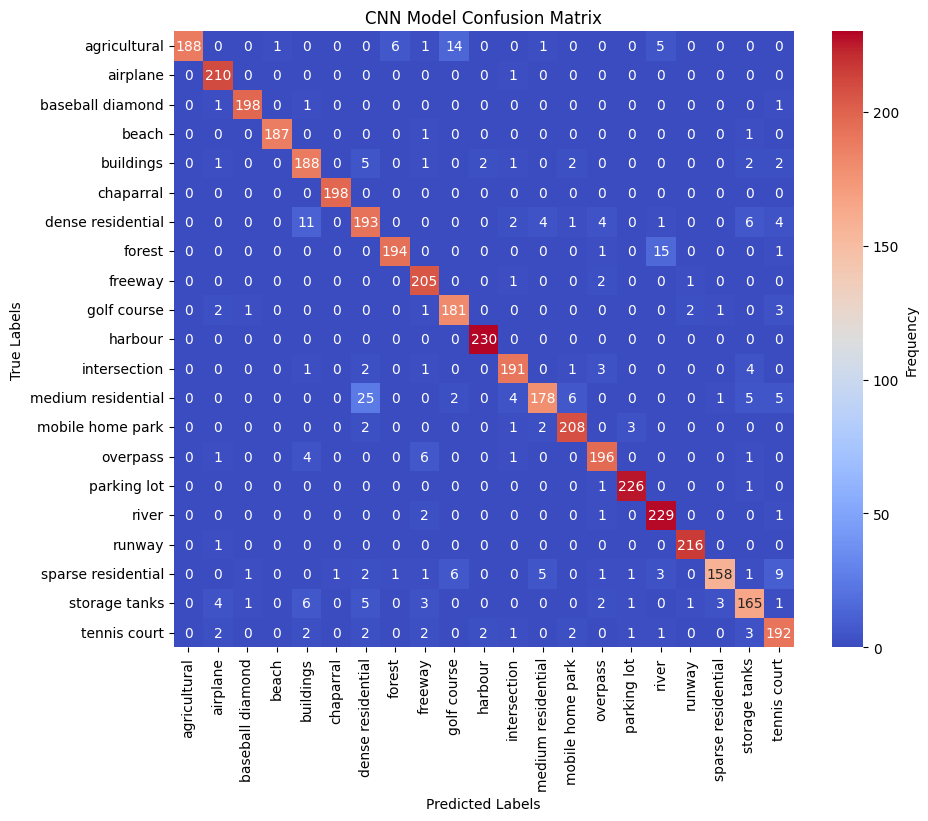

In [25]:
# Generate predictions and confusion matrix
predicted_labels_matrix = model_cnn_augmented.predict(normalized_cnn_test_data_augmented)
predicted_labels_cnn = np.argmax(predicted_labels_matrix, axis=1)
confusion_matrix_model32 = confusion_matrix(test_cnn_labels_augmented, predicted_labels_cnn)

# Customization
fig, ax = plt.subplots(figsize=(10, 8))  # Adjust figure size
sns.heatmap(confusion_matrix_model32, 
            annot=True, 
            fmt='d', 
            cmap='coolwarm',  # Change colormap
            xticklabels=label_classes,  # Adjust labels
            yticklabels=label_classes,
            cbar_kws={'label': 'Frequency'},  # Add color bar label
            ax=ax)

plt.title('CNN Model Confusion Matrix')  # Title
plt.ylabel('True Labels')  # Y-axis label
plt.xlabel('Predicted Labels')  # X-axis label
plt.show()


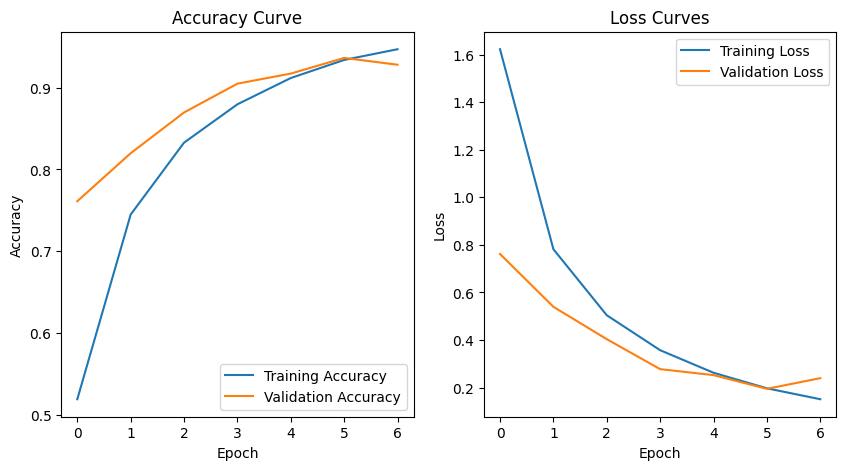

In [ ]:
plt.figure(figsize=[10,5])

#Plot lines for training vs validation accuracy
plt.subplot(121)
plt.plot(history_cnn_augmeneted.history['sparse_categorical_accuracy'])
plt.plot(history_cnn_augmeneted.history['val_sparse_categorical_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy',
           'Validation Accuracy'])
plt.title('Accuracy Curve')

#Plot lines for training vs validation loss
plt.subplot(122)
plt.plot(history_cnn_augmeneted.history['loss'])
plt.plot(history_cnn_augmeneted.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training Loss',
           'Validation Loss'])
plt.title('Loss Curves')

plt.show()

## <a id='toc7_3_'></a>[Save the data and model](#toc0_)

In [130]:
# Save the data and labels as .npy files
np.save('agumented_data.npy', augmented_images)  # Save training data
np.save('agumented_label_list.npy', augmented_label_list)  # Save training labels


In [190]:
model_cnn_augmented.save('model_cnn_terrain_validation946_test942.keras') 